# 단순선형회귀 실습1 - 카페 음료 판매량 예측
- x = 기온
- y = 음료 판매량
- 기온(°C): 10, 15, 20, 25, 30
- 판매량(잔): 20, 25, 40, 60, 80

### 1. 모델 만들기

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [3]:
X = np.array([[10],[15],[20],[25],[30]])
y = np.array([20,25,40,60,80])

In [4]:
reg = LinearRegression()
reg.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### 2. 예측하기
- 다음 기온에서의 판매량 예측하기
- 28도 / 35도 / 5도

In [5]:
pred = reg.predict(X)
pred

array([14. , 29.5, 45. , 60.5, 76. ])

In [6]:
reg.predict([[28]])

array([69.8])

In [7]:
pred_28 = reg.predict([[28]])
pred_35 = reg.predict([[35]])
pred_5 = reg.predict([[5]])
print('28도일 때 예측 판매량:', f"{pred_28[0]:.2f}잔")
print('35도일 때 예측 판매량:', f"{pred_35[0]:.2f}잔")
print('5도일 때 예측 판매량:', f"{pred_5[0]:.2f}잔")

28도일 때 예측 판매량: 69.80잔
35도일 때 예측 판매량: 91.50잔
5도일 때 예측 판매량: -1.50잔


### 3.모델 해석하기
- 기울기(w)는 얼마인가?
- 온도 1도 올라갈 때 판매량은 얼마나 변하는가
- b는 얼마인가
- "온도 0도"일 때 판매량은 몇 잔

In [8]:
print("기울기:",reg.coef_)
print("절편:",reg.intercept_)

기울기: [3.1]
절편: -16.999999999999993


Text(0, 0.5, 'Sales')

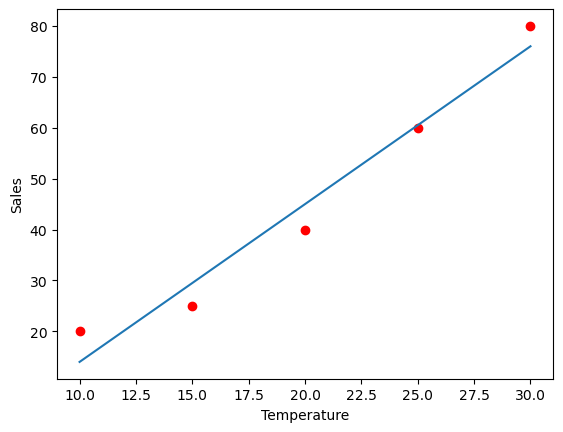

In [13]:
plt.scatter(X,y,color='r')
plt.plot(X, pred)
plt.xlabel("Temperature")
plt.ylabel("Sales")

---

## 최종 개선 및 시각화 코드 (Tip 반영)

[ 예측 결과 ]
28도일 때 예측 판매량: 69.80잔
35도일 때 예측 판매량: 91.50잔
5도일 때 예측 판매량: -1.50잔


[ 모델 해석 ]
기울기(w): 3.10 ➔ 온도가 1도 오를 때마다 판매량은 약 3.1잔씩 증가합니다.
절편(b): -17.00 ➔ 온도가 0도일 때 예상 판매량은 약 -17.0잔입니다.




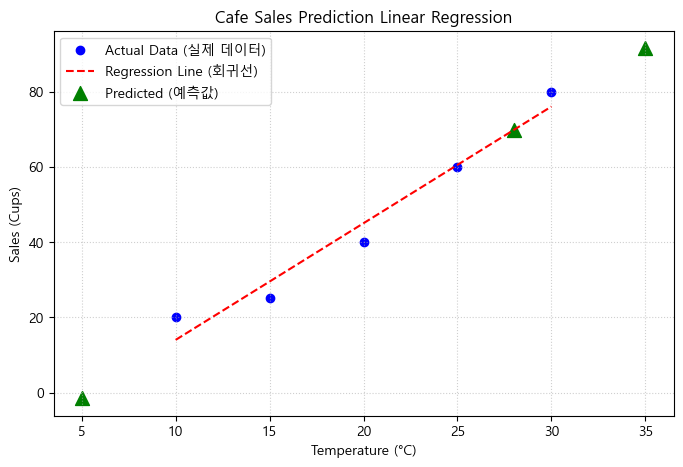

In [14]:
# 1) 여러 온도를 한 번에 예측하기 (반복문 활용)
test_temps = [[28], [35], [5]]
preds = reg.predict(test_temps)

print("[ 예측 결과 ]")
for temp, pred in zip([28, 35, 5], preds):
    print(f"{temp}도일 때 예측 판매량: {pred:.2f}잔")

print("\n" + "="*40 + "\n")

# 2) 모델 해석 출력 개선 (값만 깔끔하게 추출)
w = reg.coef_[0]       # 배열에서 값만 추출
b = reg.intercept_

print("[ 모델 해석 ]")
print(f"기울기(w): {w:.2f} ➔ 온도가 1도 오를 때마다 판매량은 약 {w:.1f}잔씩 증가합니다.")
print(f"절편(b): {b:.2f} ➔ 온도가 0도일 때 예상 판매량은 약 {b:.1f}잔입니다.")

print("\n" + "="*40 + "\n")

# 3) 시각화 추가 (상단에서 import한 matplotlib 활용)

# 한글 폰트 설정 (Windows의 기본 폰트인 맑은 고딕 사용)
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 부호(-)가 깨지는 현상 방지
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', label='Actual Data (실제 데이터)')              # 실제 데이터 점
plt.plot(X, reg.predict(X), color='red', linestyle='--', label='Regression Line (회귀선)') # 회귀선
plt.scatter([28, 35, 5], preds, color='green', marker='^', s=100, label='Predicted (예측값)') # 예측된 위치 표시

plt.xlabel('Temperature (°C)')
plt.ylabel('Sales (Cups)')
plt.title('Cafe Sales Prediction Linear Regression')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
